<h1 style="text-align: center;">Deep Learning Project</h1>

** **

## <p style="text-align: center;"><i>02 - Pre-Processing </i></p>

** **
<p style="text-align: center;">
David Cascão - 20240851 <br>
Jan-Louis Schneider - 20240506 <br>
Emir Kamiloglu - 20240945 <br>
Marta Boavida - 20240519 <br>
Sofia Gomes - 20240848
</p>


## <span style="color:#FF007F"> Notebook </span> 

In this notebook, we explore and prepare a dataset of animal images for deep learning tasks.  
We follow a structured pipeline to clean the data, relabel using CLIP, balance classes, and visualize results.  
Each step builds on the previous one, ensuring a robust and model-friendly dataset.


## <span style="color:#FF007F">Table of Contents</span>

<a class="anchor" id="top"></a>

1. [Package Installations](#one-bullet) <br>

2. [Import Libraries](#two-bullet) <br>

3. [Dataframe Structure & Config](#three-bullet) <br>

4. [CLIP-Based Relabeling](#four-bullet) <br>

5. [Data Augmentation & Balancing](#six-bullet) <br>

6. [Class Distribution Through Preprocessing](#seven-bullet) <br>


<a class="anchor" id="one-bullet"></a>

## <span style="color:#FF007F"> 1. Package Installations </span>  

<a href="#top">Top &#129033;</a>

We begin by installing the necessary libraries and pretrained models required throughout the notebook.


In [31]:
%pip install torch clip matplotlib pandas tqdm Pillow
%pip install ftfy regex tqdm
%pip install git+https://github.com/openai/CLIP.git
%pip install albumentations

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/openai/CLIP.git to c:\users\asus.laptop-sfdpa4g4\appdata\local\temp\pip-req-build-5h8mili_
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\ASUS.LAPTOP-SFDPA4G4\AppData\Local\Temp\pip-req-build-5h8mili_'


Note: you may need to restart the kernel to use updated packages.


<a class="anchor" id="two-bullet"></a>

## <span style="color:#FF007F"> 2. Import Libraries </span>  

<a href="#top">Top &#129033;</a>

Here we import all essential libraries, including utilities for image processing, machine learning, and visualization.


In [92]:
import torch
import clip
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import gc
from tqdm import tqdm
import numpy as np
import PIL.Image
from pathlib import Path
PIL.Image.MAX_IMAGE_PIXELS = 115600000 * 2 
import cv2
import albumentations as A
import random

<a class="anchor" id="three-bullet"></a>

## <span style="color:#FF007F">3. Dataframe Structure & Config</span>  

<a href="#top">Top &#129033;</a>

This section sets up the dataset structure, defines preprocessing logic, and establishes key configurations.  
It also includes helper functions to visualize class distributions.


In [ ]:

def create_preproc_dataframe(input_df):
    """receive the spit dataframe and create the preprocessed dataframe that will store all the information made in the images"""
    
    return pd.DataFrame({
        'original_class': input_df['phylum']+"_"+input_df['family'],
        'original_path': Config.DATA_ROOT / input_df['file_path'],
        'clip_class': None,
        'clip_top3_match_probs': [{}]*len(input_df),
        'clip_status': 0,
        'aug_transforms': None,
        'aug_paths': None
    }).astype({
        'clip_top3_match_probs': 'object',
        'aug_transforms': 'object',
        'aug_paths': 'object'
    })

def plot_class_evolution(df):
    """Plot class distribution along the preprocessing"""
    fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
    
    # Calculate all counts first to determine global ylim
    counts = [df['original_class'].value_counts().sort_index(),
                df['clip_class'].value_counts().sort_index(),
                df.groupby('clip_class').apply(
                    lambda x: len(x) + x['aug_paths'].apply(
                    lambda p: len(p) if p is not None else 0).sum()).sort_index()]

    global_max = max(c.max() for c in counts)

    titles = ['Original', 'After CLIP', 'After Augmentation']
    for ax, title, count in zip(axes, titles, counts):
        ax.bar(range(len(count)), count.values, width=0.8, color='0.7')
        ax.set_title(f"Class Distribution - {title}", fontsize=10)
        ax.set_ylim(0, global_max * 1.05)  # 5% padding
        ax.set_xticks([])
        ax.tick_params(axis='y', labelsize=8)
    
    plt.tight_layout()
    plt.show()


class Config:

    DATA_ROOT=Path("../data")
    SAVE_DIR=Path("../preprocessed")
    PREPROC_ROOT=Path("../data_preprocessed")

    CLIP_GRIDS = SAVE_DIR /"clip_grids"
    AUG_GRIDS = SAVE_DIR /"aug_grids"
    
    # CLIP parameters
    CLIP_THRESHOLD = 0.5
    TILE_SIZE = (224,224)  # Size of each tile for CLIP processing
    GRID_SIZE = (8, 8)  # rows, columns
    FONT_SIZE = 8
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    @classmethod
    def setup_dirs(cls):
        """generate all required directories"""
        cls.CLIP_GRIDS.mkdir(parents=True, exist_ok=True)
        cls.AUG_GRIDS.mkdir(parents=True, exist_ok=True)
        cls.PREPROC_ROOT.mkdir(parents=True, exist_ok=True)

Config.setup_dirs()


In [94]:
# Create preprocessing dataframe
train_df = pd.read_csv(Config.DATA_ROOT / "train_df.csv")
val_df = pd.read_csv(Config.DATA_ROOT / "val_df.csv")
test_df = pd.read_csv(Config.DATA_ROOT / "test_df.csv")

train_df_preproc = create_preproc_dataframe(train_df)
val_df_preproc = create_preproc_dataframe(val_df)
test_df_preproc = create_preproc_dataframe(test_df)

train_df_preproc.head()


,original_class,original_path,clip_class,clip_top3_match_probs,clip_status,aug_transforms,aug_paths
0,arthropoda_papilionidae,..\data\arthropoda_papilionidae\29510023_13054...,None,{},0,None,None
1,chordata_rhinodermatidae,..\data\chordata_rhinodermatidae\28493262_9950...,None,{},0,None,None
2,chordata_carcharhinidae,..\data\chordata_carcharhinidae\29347816_46559...,None,{},0,None,None
3,arthropoda_tettigoniidae,..\data\arthropoda_tettigoniidae\29822048_8587...,None,{},0,None,None
4,arthropoda_apidae,..\data\arthropoda_apidae\21834170_1065290_eol...,None,{},0,None,None


<a class="anchor" id="four-bullet"></a>

## <span style="color:#FF007F">4. CLIP-Based Relabeling</span>  

<a href="#top">Top &#129033;</a>

This section uses the CLIP model to remove images that do not show animals. CLIP connects images and text, so we can ask it how well an image matches a description like “a photo of an animal.” 

We compare each image to two prompts: one for animals, one for objects. If the image is closer to the animal prompt, we keep it. Otherwise, we filter it out.  

This helps clean the dataset by removing pictures that are not useful for training an animal classifier, and put them in a new class.


In [ ]:
class ClipProcessor:
    def __init__(self):
        self.device = Config.DEVICE
        self.model, self.preprocess = clip.load("ViT-B/32", device=self.device)
        self.animal_prompts = ["a clear photo of a single animal with distinct features",
            "a detailed close-up of a animal body",
            "a wild animal in natural environment with proper proportions",
            "a healthy animal in natural lighting",
            "close-up of animal face with clear features",
            "two or more animals same specie",
            "little animal",
            "animal on human hands",
            "insect",
            "amphibian",
            "mammal",
            "fish",
            "bird"]
        self.non_animal_prompts = ["scientific illustration",
            "pencil drawing of animal species",
            "geographical map or chart",
            "text document or book page",
            "trees without animals",
            "animal skeleton or bone structure",
            "landscape no animals"]
        self.all_prompts = self.animal_prompts +self.non_animal_prompts
        self.text_features = None
        self.rows, self.cols= Config.GRID_SIZE
        self.grid_capacity= self.rows * self.cols

    def _prepare_text_features(self):
        text_inputs = torch.cat([clip.tokenize(p) for p in self.all_prompts]).to(self.device)
        with torch.no_grad():
            self.text_features = self.model.encode_text(text_inputs)
            self.text_features /= self.text_features.norm(dim=-1,keepdim=True)

    def process(self, preproc_df, dataset_name="train"):
        self._prepare_text_features()
        all_results = []       
        # First pass: process all images
        for idx, row in tqdm(preproc_df.iterrows(),total=len(preproc_df),desc=f"Processing {dataset_name}"):
            result =self._process_image(row['original_path'])
            all_results.append((idx, result))
        
        # Separate results by status
        animal_results = [r for r in all_results if r[1]['status'] == 0]
        non_animal_results = [r for r in all_results if r[1]['status'] == 1]
        
        # Create grids for each category
        self._create_grid_batches(animal_results, dataset_name, "animal")
        self._create_grid_batches(non_animal_results, dataset_name, "non_animal")
        return self._update_dataframe(preproc_df, all_results)

    def _process_image(self, image_path):
        image = Image.open(image_path).convert("RGB")
        image_tensor = self.preprocess(image).unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            image_features = self.model.encode_image(image_tensor)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            logits = (100.0 * image_features @ self.text_features.T).softmax(dim=-1)
        
        probs, indices = logits.topk(3)
        top_prompt= self.all_prompts[indices[0][0]]
        top_prob= float(probs[0][0])
        status = 1 if (top_prompt in self.non_animal_prompts) and (top_prob > Config.CLIP_THRESHOLD) else 0
        return {
            "path": image_path,
            "predictions": {self.all_prompts[i]: float(p) for p, i in zip(probs[0], indices[0])},
            "status": status
        }
    


    def _create_grid_batches(self, results, dataset_name, status):
        """Create batches of grids for a specific status"""
        for batch_idx in range(0, len(results), self.grid_capacity):
            batch = results[batch_idx:batch_idx + self.grid_capacity]
            self._create_single_grid(batch, dataset_name, status, batch_idx//self.grid_capacity)
            gc.collect()

    def _create_single_grid(self, batch, dataset_name, status, grid_num):
        """Create a single grid image using PIL"""
        tile_size = Config.TILE_SIZE
        grid_img= Image.new('RGB', (self.cols * tile_size[0], self.rows * tile_size[1]))
        draw = ImageDraw.Draw(grid_img)
        font = ImageFont.load_default()  # Consider using a larger font if needed

        for idx, (orig_idx, result) in enumerate(batch):
            if idx >= self.grid_capacity:
                break
            try:
                # Calculate position
                row = idx // self.cols
                col = idx % self.cols
                x = col * tile_size[0]
                y = row * tile_size[1]

                # Process image with context manager
                with Image.open(result['path']) as img:
                    # Resize and convert to RGB
                    img = img.convert('RGB').resize(tile_size, Image.LANCZOS)
                    
                    # Paste into grid
                    grid_img.paste(img, (x, y))
                    
                    # Add text annotation
                    top_prompt = list(result['predictions'].keys())[0][:20]
                    prob=list(result['predictions'].values())[0]
                    text = f"{top_prompt}\n{prob:.2f}"
                    
                    # Draw text with background
                    draw.rectangle((x, y, x + tile_size[0], y + 20 * 2), fill='black')
                    draw.text((x + 5, y + 5), text, font=font, fill='white')

            except Exception as e:
                print(f"Skipping image {result['path']} due to error: {str(e)}")
                continue

        # Save grid
        output_dir = Config.CLIP_GRIDS / dataset_name / status
        output_dir.mkdir(parents=True, exist_ok=True)
        grid_path = output_dir / f"grid_{grid_num:03d}.png"
        
        try:
            grid_img.save(grid_path, quality=85, optimize=True)
        except Exception as e:
            print(f"Failed to save grid {grid_path}: {str(e)}")
        
        # cleaneing because of memory problems
        del grid_img
        del draw
        gc.collect()



    def _update_dataframe(self, df, results):
        df['clip_top3_match_probs'] = [res[1]['predictions'] for res in results]
        df['clip_status']=[res[1]['status'] for res in results]
        df['clip_class'] = ["non_animal" if res[1]['status'] == 1 else df.loc[res[0], 'original_class'] for res in results]
        return df

In [96]:
# Initialize processor
clip_processor = ClipProcessor()

# Process with CLIP
train_df_preproc_clip = clip_processor.process(train_df_preproc, dataset_name="train")
val_df_preproc_clip = clip_processor.process(val_df_preproc, dataset_name="val")
test_df_preproc_clip = clip_processor.process(test_df_preproc, dataset_name="test")

# Save results
train_df_preproc_clip
val_df_preproc_clip.to_csv(Config.SAVE_DIR / "val_df_preproc_clip.csv", index=False)
test_df_preproc_clip.to_csv(Config.SAVE_DIR / "test_df_preproc_clip.csv", index=False)


Processing test: 100%|██████████| 1199/1199 [08:23<00:00,  2.38it/s]


<a class="anchor" id="six-bullet"></a>

## <span style="color:#FF007F">5. Data Augmentation & Balancing</span>  

<a href="#top">Top &#129033;</a>


This section generates new images from existing ones to balance the dataset across classes. 

It uses a smart plan to decide how many new images each class needs, based on how common it is. Transformations like flipping, rotating, and changing colors are applied using Albumentations.
  
This helps make the model more robust and fair across all animal types.


In [ ]:
class AugmentationProcessor:
    def __init__(self, balance_factor, max_aug, max_variance):
        self.balance_factor = balance_factor
        self.max_aug = max_aug
        self.max_variance = max_variance
        self.aug_transform = self._build_replay_pipeline()
        self.grid_counter = 0
        self.current_grid = None
        self.current_images = []
        self.non_animal_count = 0

    def _calculate_augmentation_plan(self, df):
        self.non_animal_count = (df['clip_class']== 'non_animal').sum()
        animal_df = df[df['clip_class'] != 'non_animal']
        class_counts= animal_df.groupby('original_class').size()
        sorted_classes = sorted(class_counts.items(), key=lambda x: x[1])
        
        self.aug_plan = {}
        num_classes= len(sorted_classes)
        base_target = self.non_animal_count * self.balance_factor if self.non_animal_count > 0 \
                     else class_counts.max() * self.balance_factor

        for idx, (cls, count) in enumerate(sorted_classes):
            scaling_factor = (1 -self.max_variance) + (self.max_variance* (idx/max(num_classes-1,1)))
            target = int(base_target * scaling_factor)
            needed = max(target - count, 0)
            
            per_image = min((needed // count) + (1 if (needed % count) > np.random.rand() else 0), 
                          self.max_aug) if needed and count else 0

            self.aug_plan[cls] = {
                'per_image':per_image,
                'total_target':target,
                'original_count': count
            }

            print(f"Class: {cls:<25} | Original:{count:<4} | Target: {target:<4} "
                  f"| Needed: {needed:<4} | Aug/img: {per_image}")

    def _build_replay_pipeline(self):
        return A.ReplayCompose([
    A.Resize(512, 512),
    A.Affine(scale=(0.7, 1.7),keep_ratio=True,fit_output=True,p=0.7),
    A.PadIfNeeded(512, 512, border_mode=cv2.BORDER_REFLECT101),
    A.HorizontalFlip(p=0.4),
    A.Rotate(limit=45, border_mode=cv2.BORDER_REFLECT101, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.2, p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.ElasticTransform(p=0.2)
], p=1)

    def process(self, df, dataset_type="train", save_images=False):
        df["aug_paths"] = [[] for _ in range(len(df))]
        df["aug_transforms"] =[[] for _ in range(len(df))]
        valid_df = df[df['clip_class']!= 'non_animal'] #exclude non animal beacause is already too many
        self._calculate_augmentation_plan(valid_df)
        
        if not save_images:
            self._init_new_grid()

        for cls in tqdm(self.aug_plan, desc="Augmenting classes"):
            for idx, row in valid_df[valid_df['clip_class'] == cls].iterrows():
                try:
                    with Image.open(row['original_path']) as img:
                        img_array =np.array(img.convert('RGB'))
                        
                        base_aug= self.aug_plan[cls]['per_image']
                        aug_count = max(0, min(base_aug + np.random.randint(-1, 2), self.max_aug))
                        
                        aug_paths = []
                        aug_transforms = []
                        
                        for aug_num in range(aug_count):
                            transformed = self.aug_transform(image=img_array)
                            augmented = transformed['image']
                            
                            if save_images:
                                save_path= self._save_augmented(
                                    augmented, row['original_path'], cls, dataset_type, aug_num
                                )
                                aug_paths.append(str(save_path))
                                aug_transforms.append(transformed['replay'])
                            else:
                                self._add_to_grid(augmented)

                            df.at[idx, "aug_paths"] = aug_paths
                            df.at[idx, "aug_transforms"] = aug_transforms

                except Exception as e:
                    print(f"Skipping {row['original_path']}: {str(e)}")

        if not save_images and self.current_images:
            self._save_current_grid()

        return df

    def _save_augmented(self, image, source_path, class_name, dataset_type, aug_num):
        save_dir= Config.PREPROC_ROOT / dataset_type / class_name
        save_dir.mkdir(parents=True, exist_ok=True)
        save_path = save_dir / f"aug_{aug_num:03d}_{Path(source_path).name}"
        Image.fromarray(image).save(save_path)
        return save_path


    def _add_to_grid(self, image):
        """Add to grid visualization"""
        pil_img= Image.fromarray(image).resize(Config.TILE_SIZE)
        self.current_images.append(pil_img)
        
        if len(self.current_images) >= Config.GRID_SIZE[0] * Config.GRID_SIZE[1]:
            self._save_current_grid()
            self._init_new_grid()

    def _init_new_grid(self):
        self.current_grid = Image.new('RGB', 
            (Config.GRID_SIZE[1] * Config.TILE_SIZE[0], 
             Config.GRID_SIZE[0] * Config.TILE_SIZE[1]))
        self.current_images = []

    def _save_current_grid(self):
        if not self.current_images:
            return

        for idx, img in enumerate(self.current_images):
            row = idx // Config.GRID_SIZE[1]
            col= idx % Config.GRID_SIZE[1]
            x = col * Config.TILE_SIZE[0]
            y = row * Config.TILE_SIZE[1]
            self.current_grid.paste(img, (x, y))

        self.current_grid.save(Config.AUG_GRIDS / f"grid_{self.grid_counter:03d}.png")
        self.grid_counter += 1
        self.current_grid.close()
        self._init_new_grid()

In [98]:

aug_processor = AugmentationProcessor(balance_factor=0.95, max_aug=15, max_variance=0.05)

train_df_preproc_clip_aug = aug_processor.process(train_df_preproc_clip, dataset_type="train", save_images=False)# to check results

train_df_preproc_clip_aug = aug_processor.process(train_df_preproc_clip, dataset_type="train", save_images=True)

train_df_preproc_clip_aug

Class: mollusca_conidae          | Original: 13   | Target: 196  | Needed: 183  | Aug/img: 15
Class: chordata_pristidae        | Original: 14   | Target: 196  | Needed: 182  | Aug/img: 13
Class: chordata_brachypteraciidae | Original: 15   | Target: 196  | Needed: 181  | Aug/img: 13
Class: chordata_vangidae         | Original: 15   | Target: 196  | Needed: 181  | Aug/img: 13
Class: chordata_balaenicipitidae | Original: 18   | Target: 196  | Needed: 178  | Aug/img: 10
Class: chordata_pontoporiidae    | Original: 18   | Target: 197  | Needed: 179  | Aug/img: 10
Class: chordata_siluridae        | Original: 18   | Target: 197  | Needed: 179  | Aug/img: 10
Class: chordata_strigopidae      | Original: 18   | Target: 197  | Needed: 179  | Aug/img: 10
Class: chordata_callorhinchidae  | Original: 19   | Target: 197  | Needed: 178  | Aug/img: 10
Class: chordata_cetorhinidae     | Original: 19   | Target: 197  | Needed: 178  | Aug/img: 10
Class: chordata_giraffidae       | Original: 19   | Target:

Augmenting classes: 100%|██████████| 202/202 [32:09<00:00,  9.55s/it]


Class: mollusca_conidae          | Original: 13   | Target: 196  | Needed: 183  | Aug/img: 15
Class: chordata_pristidae        | Original: 14   | Target: 196  | Needed: 182  | Aug/img: 13
Class: chordata_brachypteraciidae | Original: 15   | Target: 196  | Needed: 181  | Aug/img: 13
Class: chordata_vangidae         | Original: 15   | Target: 196  | Needed: 181  | Aug/img: 13
Class: chordata_balaenicipitidae | Original: 18   | Target: 196  | Needed: 178  | Aug/img: 10
Class: chordata_pontoporiidae    | Original: 18   | Target: 197  | Needed: 179  | Aug/img: 10
Class: chordata_siluridae        | Original: 18   | Target: 197  | Needed: 179  | Aug/img: 10
Class: chordata_strigopidae      | Original: 18   | Target: 197  | Needed: 179  | Aug/img: 10
Class: chordata_callorhinchidae  | Original: 19   | Target: 197  | Needed: 178  | Aug/img: 10
Class: chordata_cetorhinidae     | Original: 19   | Target: 197  | Needed: 178  | Aug/img: 10
Class: chordata_giraffidae       | Original: 19   | Target:

Augmenting classes: 100%|██████████| 202/202 [40:27<00:00, 12.02s/it]  


,original_class,original_path,clip_class,clip_top3_match_probs,clip_status,aug_transforms,aug_paths
0,arthropoda_papilionidae,..\data\arthropoda_papilionidae\29510023_13054...,arthropoda_papilionidae,"{'insect': 0.3370007574558258, 'a healthy anim...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",[..\data_preprocessed\train\arthropoda_papilio...
1,chordata_rhinodermatidae,..\data\chordata_rhinodermatidae\28493262_9950...,chordata_rhinodermatidae,"{'insect': 0.29881036281585693, 'scientific il...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",[..\data_preprocessed\train\chordata_rhinoderm...
2,chordata_carcharhinidae,..\data\chordata_carcharhinidae\29347816_46559...,chordata_carcharhinidae,"{'animal on human hands': 0.3224937319755554, ...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",[..\data_preprocessed\train\chordata_carcharhi...
3,arthropoda_tettigoniidae,..\data\arthropoda_tettigoniidae\29822048_8587...,arthropoda_tettigoniidae,"{'insect': 0.7299895286560059, 'a detailed clo...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",[..\data_preprocessed\train\arthropoda_tettigo...
4,arthropoda_apidae,..\data\arthropoda_apidae\21834170_1065290_eol...,arthropoda_apidae,"{'insect': 0.3581487238407135, 'a clear photo ...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",[..\data_preprocessed\train\arthropoda_apidae\...
...,...,...,...,...,...,...,...
8982,chordata_plethodontidae,..\data\chordata_plethodontidae\29448032_33617...,chordata_plethodontidae,"{'amphibian': 0.4800926446914673, 'a clear pho...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",[..\data_preprocessed\train\chordata_plethodon...
8983,chordata_leporidae,..\data\chordata_leporidae\29734637_1011315_eo...,chordata_leporidae,{'a wild animal in natural environment with pr...,0,"[{'__class_fullname__': 'ReplayCompose', 'para...",[..\data_preprocessed\train\chordata_leporidae...
8984,chordata_rallidae,..\data\chordata_rallidae\29716097_45509132_eo...,chordata_rallidae,{'a clear photo of a single animal with distin...,0,"[{'__class_fullname__': 'ReplayCompose', 'para...",[..\data_preprocessed\train\chordata_rallidae\...
8985,chordata_ciconiidae,..\data\chordata_ciconiidae\20703734_1049138_e...,chordata_ciconiidae,"{'bird': 0.7207908630371094, 'a clear photo of...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",[..\data_preprocessed\train\chordata_ciconiida...


In [99]:
train_df_preproc_clip_aug.to_csv(Config.SAVE_DIR / "train_df_preproc_clip_aug.csv", index=False)

<a class="anchor" id="seven-bullet"></a>

## <span style="color:#FF007F"> 6. Class Distribution Through Preprocessing</span>  

<a href="#top">Top &#129033;</a>

This section shows how the class distribution changes through each preprocessing stage:  
original labels, CLIP relabeling, background removal, and augmentation.  
It uses visual plots to help ensure that no major imbalance was introduced along the way.


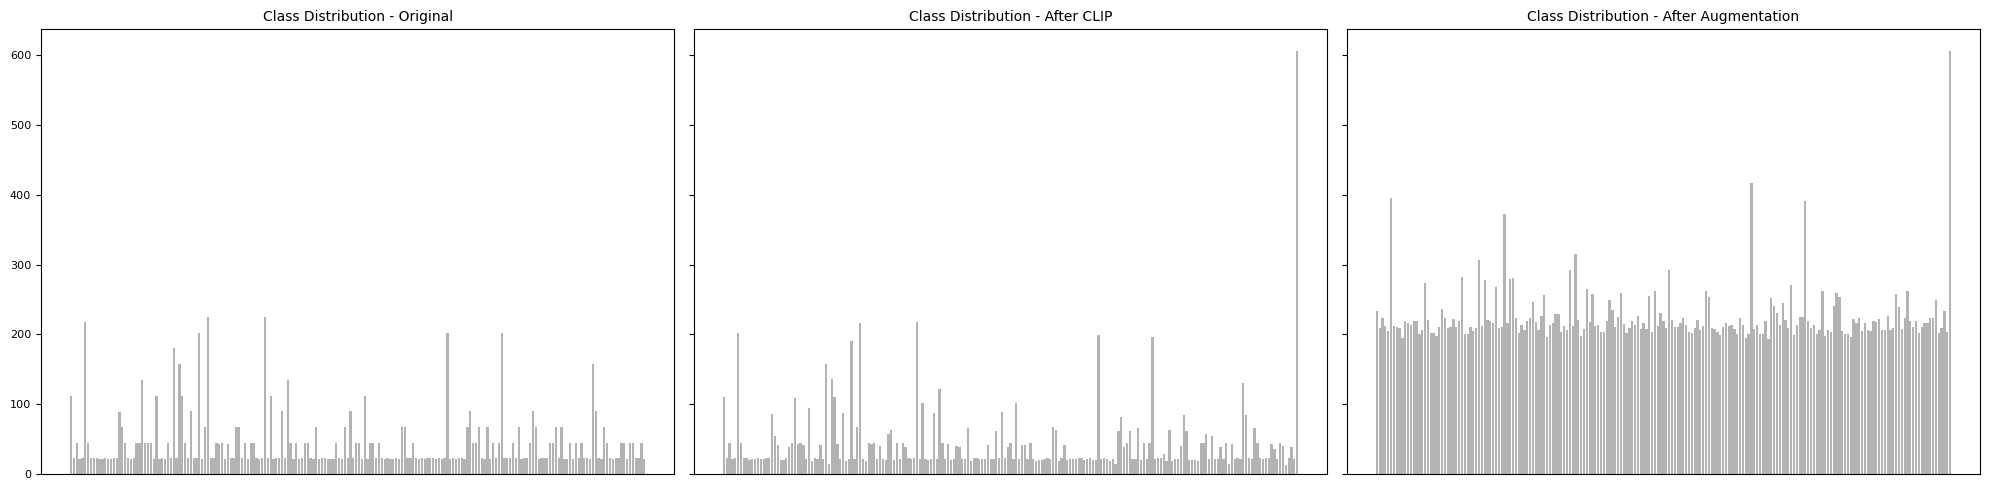

In [100]:
plot_class_evolution(train_df_preproc_clip_aug)